# MediPredict Hospital — NTI Graduation Project

Synthetic educational hospital dataset with **1,100,000 appointment records**.

Target classes:
- Healthy
- Diabetes
- Chronic Kidney Disease
- Anemia
- Liver Disease

Workflow:
1. EDA
2. Outlier and missing-value checks
3. Data cleaning
4. RFM analysis
5. Machine-learning disease classification




## Step 1: Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


## Step 2: Load Data and Create Backup

In [4]:
hospital = pd.read_csv("MediPredict_Hospital_1_1M_Raw.csv")
hospital_backup = hospital.copy()


## Step 3: Exploratory Data Analysis

In [5]:
hospital.head()


,AppointmentID,PatientID,VisitDate,Country,City,Gender,PatientAge,Department,VisitChannel,PaymentMethod,...,eGFR,BUN,Hemoglobin,Ferritin,RBC,ALT,AST,Bilirubin,Albumin,Diagnosis
0,APT0000000001,PAT0012067,2026-07-05,Saudi Arabia,Riyadh,Male,46.0,General Medicine,Website,Insurance,...,108.75,16.65,14.49,74.48,4.90,25.81,19.11,0.72,4.64,Healthy
1,APT0000000002,PAT0101433,2025.03.27,India,Mumbai,Female,29.0,Hematology,Website,Digital Wallet,...,106.63,11.72,8.40,10.72,3.01,19.84,23.41,0.84,4.25,Anemia
2,APT0000000003,PAT0093877,10/08/2024,Turkey,Antalya,Female,34.0,Nephrology,Call Center,Insurance,...,41.36,40.72,13.21,102.08,5.01,18.19,23.83,0.51,4.34,Chronic Kidney Disease
3,APT0000000004,PAT0013330,2024-11-15,Egypt,Aswan,Female,32.0,Hematology,Mobile App,Insurance,...,91.17,13.50,8.32,20.07,3.22,28.57,19.11,0.73,4.90,Anemia
4,APT0000000005,PAT0153644,2025-08-31,Egypt,Giza,Female,57.0,Hepatology,Hospital Reception,Cash,...,87.09,19.90,12.93,92.99,5.00,92.26,83.99,2.13,3.43,Liver Disease


In [6]:
hospital.tail()


,AppointmentID,PatientID,VisitDate,Country,City,Gender,PatientAge,Department,VisitChannel,PaymentMethod,...,eGFR,BUN,Hemoglobin,Ferritin,RBC,ALT,AST,Bilirubin,Albumin,Diagnosis
1099995,APT0000009996,PAT0058370,2023-09-27,Morocco,Rabat,Male,40.0,Nephrology,Hospital Reception,Credit Card,...,43.49,46.45,12.96,81.67,4.34,34.89,25.25,0.85,4.59,Chronic Kidney Disease
1099996,APT0000009997,PAT0068848,2025-05-20,Saudi Arabia,Jeddah,Male,44.0,Hematology,Website,Credit Card,...,92.37,18.27,9.36,14.03,3.04,30.61,20.55,0.98,4.37,Anemia
1099997,APT0000009998,PAT0173195,2025-08-25,Egypt,Giza,Male,49.0,Endocrinology,Hospital Reception,Digital Wallet,...,92.82,15.62,14.29,76.51,4.44,28.13,22.42,0.87,4.20,Diabetes
1099998,APT0000009999,PAT0159550,2026-06-05,Jordan,Irbid,Male,38.0,Endocrinology,Hospital Reception,Credit Card,...,104.97,11.01,13.20,118.12,4.66,32.79,20.23,0.92,4.51,Diabetes
1099999,APT0000010000,PAT0041609,2026-06-08,TR,Antalya,Female,31.0,General Medicine,Website,Credit Card,...,103.04,12.07,13.73,84.48,4.70,29.13,26.88,0.59,4.56,Healthy


In [7]:
hospital.sample(10)


,AppointmentID,PatientID,VisitDate,Country,City,Gender,PatientAge,Department,VisitChannel,PaymentMethod,...,eGFR,BUN,Hemoglobin,Ferritin,RBC,ALT,AST,Bilirubin,Albumin,Diagnosis
792652,APT0000792653,PAT0007218,25/02/2024,Egypt,Aswan,Female,22.0,Hepatology,Hospital Reception,Credit Card,...,118.01,14.92,14.10,86.42,4.96,103.15,96.49,2.81,3.05,Liver Disease
752511,APT0000752512,PAT0073868,2025-04-19,Germany,Berlin,Female,35.0,General Medicine,Mobile App,Insurance,...,108.37,16.92,13.16,50.29,4.91,32.16,27.04,0.81,4.60,Healthy
551897,APT0000551898,PAT0151882,2025-02-25,Egypt,Giza,Female,47.0,Hematology,Hospital Reception,Digital Wallet,...,109.68,18.33,9.70,11.28,3.60,34.35,21.39,0.75,4.22,Anemia
1077637,APT0001077638,PAT0006108,2024-11-22,Egypt,Mansoura,Female,31.0,Nephrology,Call Center,Digital Wallet,...,33.15,28.13,14.37,101.04,4.79,12.95,25.05,0.72,4.56,Chronic Kidney Disease
902037,APT0000902038,PAT0127148,2025-07-09,Saudi Arabia,Al Khobar,Male,42.0,Hepatology,Hospital Reception,Cash,...,109.69,15.39,13.62,80.38,4.75,120.70,79.07,2.54,3.51,Liver Disease
53053,APT0000053054,PAT0152438,2026-03-31,Morocco,Rabat,Female,40.0,Hematology,Hospital Reception,Insurance,...,106.92,20.76,9.99,12.52,2.99,25.27,30.49,0.78,4.62,Anemia
699873,APT0000699874,PAT0020855,18/06/2025,Turkey,Ankara,Female,22.0,Nephrology,Mobile App,Digital Wallet,...,29.31,37.43,14.37,93.99,4.95,23.37,25.75,0.51,4.18,Chronic Kidney Disease
1021780,APT0001021781,PAT0033034,2025.02.19,Jordan,Amman,Male,38.0,General Medicine,Mobile App,Insurance,...,115.06,16.93,14.00,105.76,4.71,24.86,25.99,0.80,4.10,Healthy
651520,APT0000651521,PAT0080230,19/06/2024,Turkey,Antalya,Male,26.0,Hepatology,Hospital Reception,Insurance,...,110.17,19.11,15.25,89.85,4.71,125.79,100.97,2.06,3.50,Liver Disease
865415,APT0000865416,PAT0059051,2025.03.03,Egypt,Mansoura,Male,64.0,Hepatology,Hospital Reception,Cash,...,92.82,14.10,15.08,91.49,4.72,111.29,106.98,2.74,3.43,Liver Disease


In [8]:
hospital.shape


(1100000, 33)

In [9]:
hospital.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100000 entries, 0 to 1099999
Data columns (total 33 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   AppointmentID       1100000 non-null  object 
 1   PatientID           1100000 non-null  object 
 2   VisitDate           1100000 non-null  object 
 3   Country             1091181 non-null  object 
 4   City                1100000 non-null  object 
 5   Gender              1100000 non-null  object 
 6   PatientAge          1095603 non-null  float64
 7   Department          1100000 non-null  object 
 8   VisitChannel        1095595 non-null  object 
 9   PaymentMethod       1093401 non-null  object 
 10  BookingLeadDays     1096705 non-null  float64
 11  ServicesCount       1100000 non-null  int64  
 12  ConsultationFeeUSD  1095592 non-null  float64
 13  LabCostUSD          1100000 non-null  float64
 14  TotalBillUSD        1100000 non-null  float64
 15  SatisfactionSco

In [10]:
hospital.describe(include="all")


,AppointmentID,PatientID,VisitDate,Country,City,Gender,PatientAge,Department,VisitChannel,PaymentMethod,...,eGFR,BUN,Hemoglobin,Ferritin,RBC,ALT,AST,Bilirubin,Albumin,Diagnosis
count,1100000,1100000,1100000,1091181,1100000,1100000,1.095603e+06,1100000,1095595,1093401,...,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1100000
unique,1090000,167247,3924,14,27,2,NaN,5,4,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,APT0000009985,PAT0079092,2026-07-15,Egypt,Aswan,Male,NaN,General Medicine,Hospital Reception,Insurance,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Healthy
freq,2,56,798,315571,66502,551256,NaN,259604,415704,524528,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,259604
mean,NaN,NaN,NaN,NaN,NaN,NaN,4.299160e+01,NaN,NaN,NaN,...,9.036011e+01,2.036432e+01,1.303822e+01,7.804950e+01,4.507685e+00,3.954915e+01,3.538594e+01,1.059016e+00,4.149826e+00,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,1.048229e+01,NaN,NaN,NaN,...,2.709605e+01,1.154392e+01,2.138358e+00,3.198431e+01,6.554534e-01,3.165769e+01,2.709610e+01,6.854483e-01,4.623592e-01,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2.200000e+01,NaN,NaN,NaN,...,2.000000e+01,8.000000e+00,7.200000e+00,6.000000e+00,2.600000e+00,1.200000e+01,1.100000e+01,3.500000e-01,2.700000e+00,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,3.600000e+01,NaN,NaN,NaN,...,9.136000e+01,1.375000e+01,1.285000e+01,7.049000e+01,4.440000e+00,2.245000e+01,2.047000e+01,6.700000e-01,4.100000e+00,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,4.300000e+01,NaN,NaN,NaN,...,1.005800e+02,1.576000e+01,1.376000e+01,8.756000e+01,4.730000e+00,2.641000e+01,2.441000e+01,7.900000e-01,4.300000e+00,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e+01,NaN,NaN,NaN,...,1.069800e+02,1.865000e+01,1.440000e+01,9.950000e+01,4.930000e+00,3.191000e+01,2.991000e+01,9.600000e-01,4.440000e+00,NaN


In [11]:
hospital.columns


Index(['AppointmentID', 'PatientID', 'VisitDate', 'Country', 'City', 'Gender',
       'PatientAge', 'Department', 'VisitChannel', 'PaymentMethod',
       'BookingLeadDays', 'ServicesCount', 'ConsultationFeeUSD', 'LabCostUSD',
       'TotalBillUSD', 'SatisfactionScore', 'VisitStatus', 'BMI', 'SystolicBP',
       'DiastolicBP', 'FastingGlucose', 'HbA1c', 'Creatinine', 'eGFR', 'BUN',
       'Hemoglobin', 'Ferritin', 'RBC', 'ALT', 'AST', 'Bilirubin', 'Albumin',
       'Diagnosis'],
      dtype='object')

In [12]:
hospital["Country"].unique()


array(['Saudi Arabia', 'India', 'Turkey', 'Egypt', 'Morocco',
       'United Arab Emirates', 'Jordan', 'EG', 'Germany', nan, 'DE', 'TR',
       'UAE', 'KSA', 'IN'], dtype=object)

In [13]:
hospital["PaymentMethod"].mode()


0    Insurance
Name: PaymentMethod, dtype: object

In [14]:
hospital["VisitChannel"].mode()


0    Hospital Reception
Name: VisitChannel, dtype: object

In [15]:
round(hospital["SatisfactionScore"].mean())


3

In [16]:
round(hospital["PatientAge"].mean())


43

## Step 4: Check Outliers in Numeric Columns with Missing Values

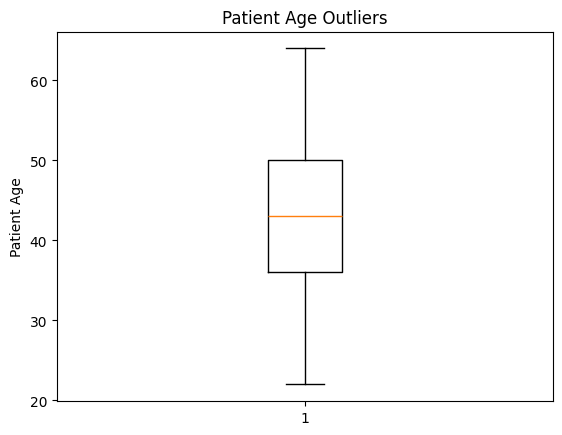

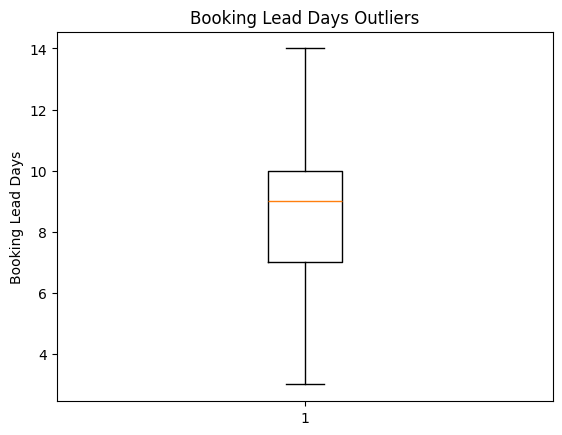

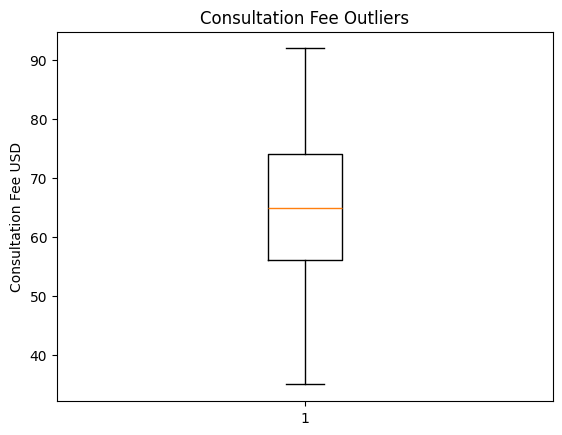

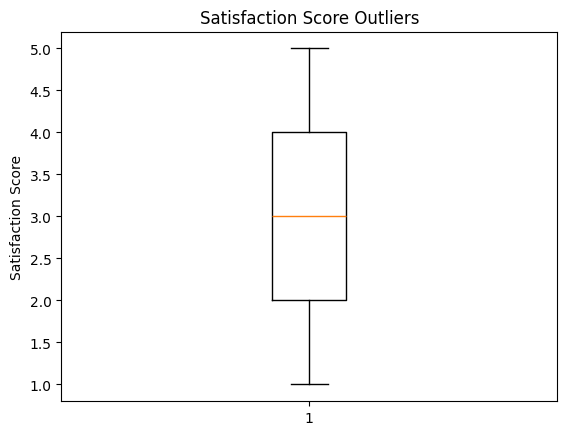

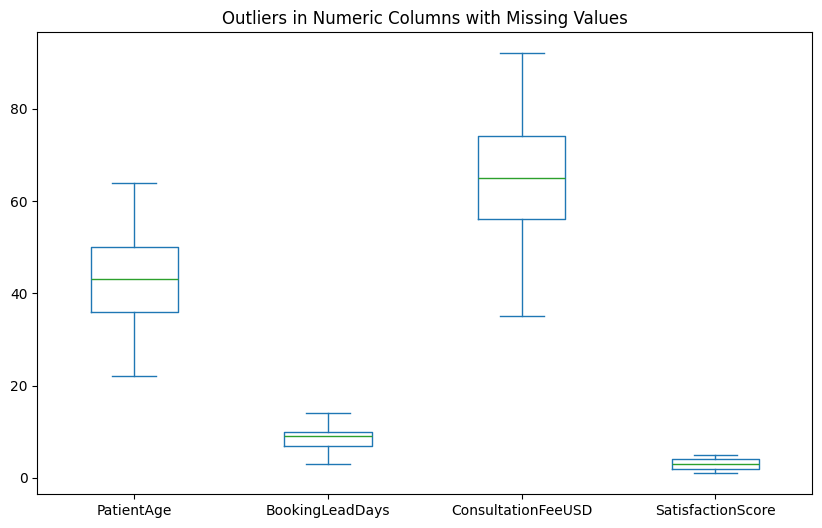

Number of PatientAge outliers: 0
Number of BookingLeadDays outliers: 0
Number of ConsultationFeeUSD outliers: 0
Number of SatisfactionScore outliers: 0


In [17]:
plt.boxplot(hospital["PatientAge"].dropna())
plt.title("Patient Age Outliers")
plt.ylabel("Patient Age")
plt.show()

plt.boxplot(hospital["BookingLeadDays"].dropna())
plt.title("Booking Lead Days Outliers")
plt.ylabel("Booking Lead Days")
plt.show()

plt.boxplot(hospital["ConsultationFeeUSD"].dropna())
plt.title("Consultation Fee Outliers")
plt.ylabel("Consultation Fee USD")
plt.show()

plt.boxplot(hospital["SatisfactionScore"].dropna())
plt.title("Satisfaction Score Outliers")
plt.ylabel("Satisfaction Score")
plt.show()

hospital[
    [
        "PatientAge",
        "BookingLeadDays",
        "ConsultationFeeUSD",
        "SatisfactionScore"
    ]
].plot(kind="box", figsize=(10, 6))

plt.title("Outliers in Numeric Columns with Missing Values")
plt.show()


Q1_age = hospital["PatientAge"].quantile(0.25)
Q3_age = hospital["PatientAge"].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = hospital[
    (hospital["PatientAge"] < lower_age) |
    (hospital["PatientAge"] > upper_age)
]


Q1_lead = hospital["BookingLeadDays"].quantile(0.25)
Q3_lead = hospital["BookingLeadDays"].quantile(0.75)
IQR_lead = Q3_lead - Q1_lead
lower_lead = Q1_lead - 1.5 * IQR_lead
upper_lead = Q3_lead + 1.5 * IQR_lead

lead_outliers = hospital[
    (hospital["BookingLeadDays"] < lower_lead) |
    (hospital["BookingLeadDays"] > upper_lead)
]


Q1_fee = hospital["ConsultationFeeUSD"].quantile(0.25)
Q3_fee = hospital["ConsultationFeeUSD"].quantile(0.75)
IQR_fee = Q3_fee - Q1_fee
lower_fee = Q1_fee - 1.5 * IQR_fee
upper_fee = Q3_fee + 1.5 * IQR_fee

fee_outliers = hospital[
    (hospital["ConsultationFeeUSD"] < lower_fee) |
    (hospital["ConsultationFeeUSD"] > upper_fee)
]


Q1_score = hospital["SatisfactionScore"].quantile(0.25)
Q3_score = hospital["SatisfactionScore"].quantile(0.75)
IQR_score = Q3_score - Q1_score
lower_score = Q1_score - 1.5 * IQR_score
upper_score = Q3_score + 1.5 * IQR_score

score_outliers = hospital[
    (hospital["SatisfactionScore"] < lower_score) |
    (hospital["SatisfactionScore"] > upper_score)
]

print("Number of PatientAge outliers:", age_outliers.shape[0])
print("Number of BookingLeadDays outliers:", lead_outliers.shape[0])
print("Number of ConsultationFeeUSD outliers:", fee_outliers.shape[0])
print("Number of SatisfactionScore outliers:", score_outliers.shape[0])


## Step 5: Check Duplicates and Missing Values

In [18]:
print("Number of duplicated values:", hospital.duplicated().sum())
print("Duplicated values %:", round(hospital.duplicated().sum() / len(hospital) * 100, 2))
print("Total null values in dataset:", hospital.isnull().sum().sum())
print("Null values per column:\n", hospital.isnull().sum())
print("Null values per column %:\n", round(hospital.isnull().sum() / len(hospital) * 100, 2))


Number of duplicated values: 10000
Duplicated values %: 0.91
Total null values in dataset: 35235
Null values per column:
 AppointmentID            0
PatientID                0
VisitDate                0
Country               8819
City                     0
Gender                   0
PatientAge            4397
Department               0
VisitChannel          4405
PaymentMethod         6599
BookingLeadDays       3295
ServicesCount            0
ConsultationFeeUSD    4408
LabCostUSD               0
TotalBillUSD             0
SatisfactionScore     3312
VisitStatus              0
BMI                      0
SystolicBP               0
DiastolicBP              0
FastingGlucose           0
HbA1c                    0
Creatinine               0
eGFR                     0
BUN                      0
Hemoglobin               0
Ferritin                 0
RBC                      0
ALT                      0
AST                      0
Bilirubin                0
Albumin                  0
Diagnosis     

## Data Cleaning

## Step 6: Fill Missing Values

In [19]:
hospital["Country"] = hospital["Country"].fillna(
    hospital["Country"].mode()[0]
)

hospital["PaymentMethod"] = hospital["PaymentMethod"].fillna(
    hospital["PaymentMethod"].mode()[0]
)

hospital["VisitChannel"] = hospital["VisitChannel"].fillna(
    hospital["VisitChannel"].mode()[0]
)

hospital["PatientAge"] = hospital["PatientAge"].fillna(
    hospital["PatientAge"].mean()
)

hospital["BookingLeadDays"] = hospital["BookingLeadDays"].fillna(
    hospital["BookingLeadDays"].mean()
)

hospital["ConsultationFeeUSD"] = hospital["ConsultationFeeUSD"].fillna(
    hospital["ConsultationFeeUSD"].mean()
)

hospital["SatisfactionScore"] = hospital["SatisfactionScore"].fillna(
    hospital["SatisfactionScore"].mean()
)


## Step 7: Remove Duplicate Rows

In [20]:
hospital.drop_duplicates(inplace=True)
hospital.duplicated().sum()


np.int64(0)

## Step 8: Correct Data Types

In [21]:
hospital["VisitDate"] = pd.to_datetime(
    hospital["VisitDate"],
    format="mixed",
    dayfirst=True
)

hospital["PatientAge"] = hospital["PatientAge"].astype("int64")
hospital["BookingLeadDays"] = hospital["BookingLeadDays"].astype("int64")
hospital["SatisfactionScore"] = hospital["SatisfactionScore"].round(2)

hospital["ConsultationFeeUSD"] = hospital["ConsultationFeeUSD"].round(2)
hospital["LabCostUSD"] = hospital["LabCostUSD"].round(2)
hospital["TotalBillUSD"] = hospital["TotalBillUSD"].round(2)


## Step 9: Replace Country Abbreviations

In [22]:
hospital["Country"] = hospital["Country"].replace({
    "EG": "Egypt",
    "KSA": "Saudi Arabia",
    "UAE": "United Arab Emirates",
    "TR": "Turkey",
    "IN": "India",
    "DE": "Germany"
})


In [23]:
hospital["Country"].unique()


array(['Saudi Arabia', 'India', 'Turkey', 'Egypt', 'Morocco',
       'United Arab Emirates', 'Jordan', 'Germany'], dtype=object)

## Step 10: Feature Engineering

In [24]:
hospital["AverageCostPerServiceUSD"] = round(
    hospital["TotalBillUSD"] / hospital["ServicesCount"],
    2
)


In [25]:
hospital["VisitDateOnly"] = hospital["VisitDate"].dt.date
hospital["Year"] = hospital["VisitDate"].dt.year
hospital["Month"] = hospital["VisitDate"].dt.month
hospital["MonthName"] = hospital["VisitDate"].dt.month_name()
hospital["Day"] = hospital["VisitDate"].dt.day
hospital["DayName"] = hospital["VisitDate"].dt.day_name()


In [26]:
hospital = hospital.sort_values(
    by="VisitDate",
    ascending=True
)

hospital.head()


,AppointmentID,PatientID,VisitDate,Country,City,Gender,PatientAge,Department,VisitChannel,PaymentMethod,...,Bilirubin,Albumin,Diagnosis,AverageCostPerServiceUSD,VisitDateOnly,Year,Month,MonthName,Day,DayName
138848,APT0000138849,PAT0032906,2023-01-01,United Arab Emirates,Sharjah,Male,40,Hematology,Mobile App,Insurance,...,0.90,4.28,Anemia,122.80,2023-01-01,2023,1,January,1,Sunday
301940,APT0000301941,PAT0082703,2023-01-01,Saudi Arabia,Jeddah,Male,56,General Medicine,Mobile App,Insurance,...,0.83,4.53,Healthy,40.41,2023-01-01,2023,1,January,1,Sunday
622550,APT0000622551,PAT0070500,2023-01-01,Saudi Arabia,Al Khobar,Male,52,Nephrology,Hospital Reception,Insurance,...,0.62,4.21,Chronic Kidney Disease,74.60,2023-01-01,2023,1,January,1,Sunday
181062,APT0000181063,PAT0044624,2023-01-01,Morocco,Marrakech,Male,53,General Medicine,Mobile App,Credit Card,...,0.93,4.45,Healthy,50.25,2023-01-01,2023,1,January,1,Sunday
303538,APT0000303539,PAT0173756,2023-01-01,Saudi Arabia,Al Khobar,Male,35,Nephrology,Website,Credit Card,...,0.97,4.29,Chronic Kidney Disease,84.48,2023-01-01,2023,1,January,1,Sunday


## Step 11: Final Cleaning Validation

In [27]:
print("Final shape:", hospital.shape)
print("Remaining null values:", hospital.isnull().sum().sum())
print("Remaining duplicated rows:", hospital.duplicated().sum())
hospital.info()


Final shape: (1090000, 40)
Remaining null values: 0
Remaining duplicated rows: 0
<class 'pandas.core.frame.DataFrame'>
Index: 1090000 entries, 138848 to 825311
Data columns (total 40 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   AppointmentID             1090000 non-null  object        
 1   PatientID                 1090000 non-null  object        
 2   VisitDate                 1090000 non-null  datetime64[ns]
 3   Country                   1090000 non-null  object        
 4   City                      1090000 non-null  object        
 5   Gender                    1090000 non-null  object        
 6   PatientAge                1090000 non-null  int64         
 7   Department                1090000 non-null  object        
 8   VisitChannel              1090000 non-null  object        
 9   PaymentMethod             1090000 non-null  object        
 10  BookingLeadDays           1090000 

## Step 12: RFM Analysis

For a hospital:
- **Recency:** days since the patient's latest completed visit.
- **Frequency:** number of completed visits.
- **Monetary:** total amount paid during completed visits.


In [28]:
rfm_data = hospital[
    hospital["VisitStatus"] == "Completed"
].copy()

snapshot_date = (
    rfm_data["VisitDate"].max()
    + pd.Timedelta(days=1)
)

rfm = rfm_data.groupby("PatientID").agg({
    "VisitDate": lambda date: (snapshot_date - date.max()).days,
    "AppointmentID": "nunique",
    "TotalBillUSD": "sum"
}).reset_index()

rfm.columns = [
    "PatientID",
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()


,PatientID,Recency,Frequency,Monetary
0,PAT0000001,225,6,669.09
1,PAT0000002,110,2,238.74
2,PAT0000003,300,5,754.34
3,PAT0000004,325,1,108.34
4,PAT0000005,11,8,1297.35


In [29]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()


,PatientID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,PAT0000001,225,6,669.09,2,4,3,243
1,PAT0000002,110,2,238.74,4,1,1,411
2,PAT0000003,300,5,754.34,2,3,3,233
3,PAT0000004,325,1,108.34,2,1,1,211
4,PAT0000005,11,8,1297.35,5,4,5,545


In [30]:
def patient_segment(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "High-Value Active Patients"
    elif row["R_Score"] >= 3 and row["F_Score"] >= 4:
        return "Frequent Patients"
    elif row["R_Score"] >= 4 and row["F_Score"] >= 2:
        return "Recently Engaged Patients"
    elif row["R_Score"] == 5 and row["F_Score"] == 1:
        return "New Patients"
    elif row["R_Score"] <= 2 and row["F_Score"] >= 4:
        return "At-Risk Returning Patients"
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "Inactive Patients"
    else:
        return "Need Follow-up"

rfm["Segment"] = rfm.apply(patient_segment, axis=1)
rfm["Monetary"] = rfm["Monetary"].round(2)

rfm["Segment"].value_counts()


Segment
Inactive Patients             43835
High-Value Active Patients    40037
Need Follow-up                33729
Recently Engaged Patients     19850
Frequent Patients             16580
At-Risk Returning Patients     9470
New Patients                   1717
Name: count, dtype: int64

In [31]:
print(
    rfm[
        [
            "PatientID",
            "Recency",
            "Frequency",
            "Monetary",
            "RFM_Score",
            "Segment"
        ]
    ].head(20)
)


     PatientID  Recency  Frequency  Monetary RFM_Score  \
0   PAT0000001      225          6    669.09       243   
1   PAT0000002      110          2    238.74       411   
2   PAT0000003      300          5    754.34       233   
3   PAT0000004      325          1    108.34       211   
4   PAT0000005       11          8   1297.35       545   
5   PAT0000006      371         10   1617.55       255   
6   PAT0000007       64          3    459.21       422   
7   PAT0000008       43          5    605.53       533   
8   PAT0000009      311          1    129.94       211   
9   PAT0000010        6          7    759.36       543   
10  PAT0000012        1          3    396.56       522   
11  PAT0000013      603          6    643.49       143   
12  PAT0000014      166          4    457.83       332   
13  PAT0000015      725          4    660.04       133   
14  PAT0000016      375          4    629.75       233   
15  PAT0000017      329          2    220.34       211   
16  PAT0000018

## Step 13: Machine Learning — Disease Classification

The model predicts one of five classes:
- Healthy
- Diabetes
- Chronic Kidney Disease
- Anemia
- Liver Disease

The selected features are laboratory and clinical measurements only.


In [32]:
ml_features = [
    "PatientAge",
    "BMI",
    "SystolicBP",
    "DiastolicBP",
    "FastingGlucose",
    "HbA1c",
    "Creatinine",
    "eGFR",
    "BUN",
    "Hemoglobin",
    "Ferritin",
    "RBC",
    "ALT",
    "AST",
    "Bilirubin",
    "Albumin"
]

X = hospital[ml_features]
y = hospital["Diagnosis"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print(y.value_counts())


Features shape: (1090000, 16)
Target shape: (1090000,)
Diagnosis
Healthy                   257240
Diabetes                  220537
Chronic Kidney Disease    208604
Anemia                    205323
Liver Disease             198296
Name: count, dtype: int64


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 872000
Testing rows: 218000


In [34]:
model = RandomForestClassifier(
    n_estimators=121,
    max_depth=12,
    min_samples_split=15,
    min_samples_leaf=6,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)


,n_estimators,121
,criterion,'gini'
,max_depth,12
,min_samples_split,15
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
train_predictions = model.predict(X_train)
y_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy:", round(train_accuracy * 100, 2), "%")
print("Testing Accuracy:", round(test_accuracy * 100, 2), "%")
print(
    "Accuracy Difference:",
    round((train_accuracy - test_accuracy) * 100, 2),
    "%"
)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Training Accuracy: 100.0 %
Testing Accuracy: 100.0 %
Accuracy Difference: 0.0 %

Classification Report:

                        precision    recall  f1-score   support

                Anemia       1.00      1.00      1.00     41065
Chronic Kidney Disease       1.00      1.00      1.00     41721
              Diabetes       1.00      1.00      1.00     44107
               Healthy       1.00      1.00      1.00     51448
         Liver Disease       1.00      1.00      1.00     39659

              accuracy                           1.00    218000
             macro avg       1.00      1.00      1.00    218000
          weighted avg       1.00      1.00      1.00    218000



In [36]:
confusion = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

confusion_table = pd.DataFrame(
    confusion,
    index=model.classes_,
    columns=model.classes_
)

confusion_table


,Anemia,Chronic Kidney Disease,Diabetes,Healthy,Liver Disease
Anemia,41065,0,0,0,0
Chronic Kidney Disease,0,41721,0,0,0
Diabetes,0,0,44107,0,0
Healthy,0,0,0,51448,0
Liver Disease,0,0,0,0,39659


In [37]:
feature_importance = pd.DataFrame({
    "Feature": ml_features,
    "Importance": model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance


,Feature,Importance
10,Ferritin,0.103367
4,FastingGlucose,0.101114
5,HbA1c,0.099859
7,eGFR,0.080937
6,Creatinine,0.077466
9,Hemoglobin,0.075226
8,BUN,0.070028
11,RBC,0.069984
15,Albumin,0.069464
14,Bilirubin,0.067530


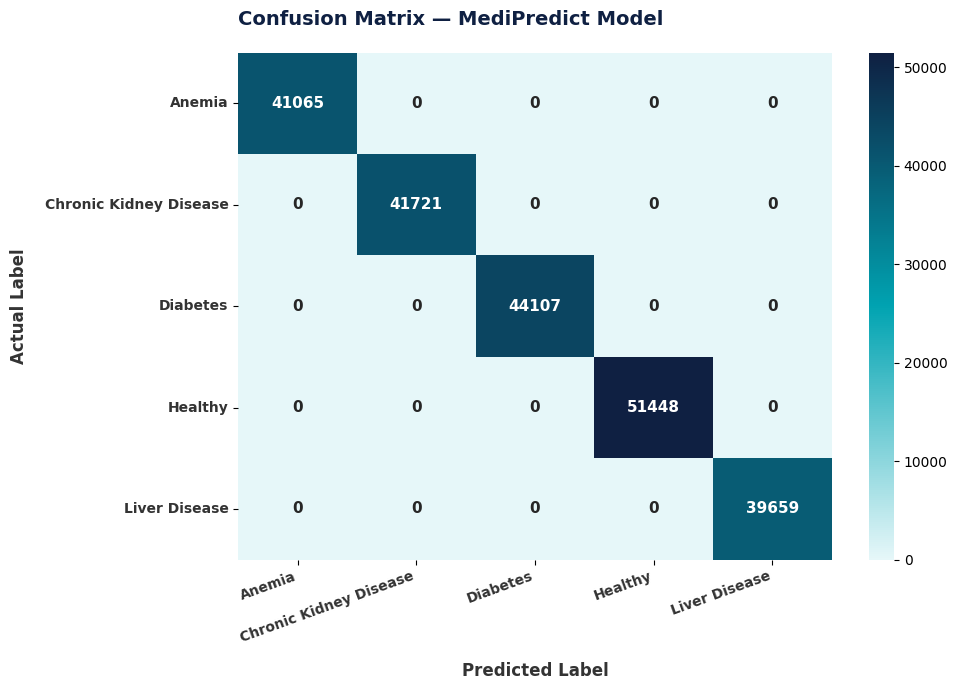

In [38]:

from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list("custom_teal_navy", ["#E6F7F9", "#00A3B1", "#0F2042"])

plt.figure(figsize=(10, 7), facecolor='white')
ax = sns.heatmap(confusion_table, annot=True, fmt='d', cmap=custom_cmap, cbar=True,
                 xticklabels=model.classes_, yticklabels=model.classes_,
                 annot_kws={"size": 11, "weight": "bold"})
plt.title('Confusion Matrix — MediPredict Model', fontsize=14, fontweight='bold', pad=20, loc='left', color='#0F2042')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=12, color='#333333')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold', labelpad=12, color='#333333')
plt.xticks(rotation=20, ha='right', fontsize=10, fontweight='bold', color='#333333')
plt.yticks(rotation=0, fontsize=10, fontweight='bold', color='#333333')
plt.tight_layout()
plt.show()


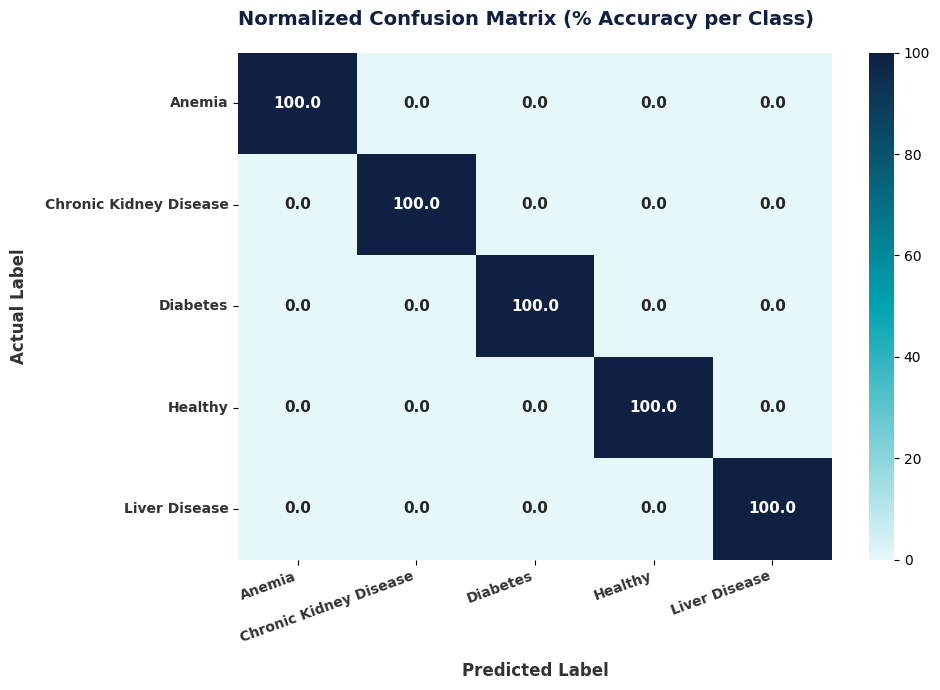

In [39]:
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_teal_navy", ["#E6F7F9", "#00A3B1", "#0F2042"])
confusion_norm = confusion_matrix(y_test, y_pred, labels=model.classes_, normalize='true') * 100
confusion_norm_df = pd.DataFrame(confusion_norm, index=model.classes_, columns=model.classes_)
plt.figure(figsize=(10, 7), facecolor='white')
ax = sns.heatmap(confusion_norm_df, annot=True, fmt='.1f', cmap=custom_cmap, cbar=True,
                 xticklabels=model.classes_, yticklabels=model.classes_,
                 annot_kws={"size": 11, "weight": "bold"})
plt.title('Normalized Confusion Matrix (% Accuracy per Class)', fontsize=14, fontweight='bold', pad=20, loc='left', color='#0F2042')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=12, color='#333333')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold', labelpad=12, color='#333333')
plt.xticks(rotation=20, ha='right', fontsize=10, fontweight='bold', color='#333333')
plt.yticks(rotation=0, fontsize=10, fontweight='bold', color='#333333')
plt.tight_layout()
plt.show()

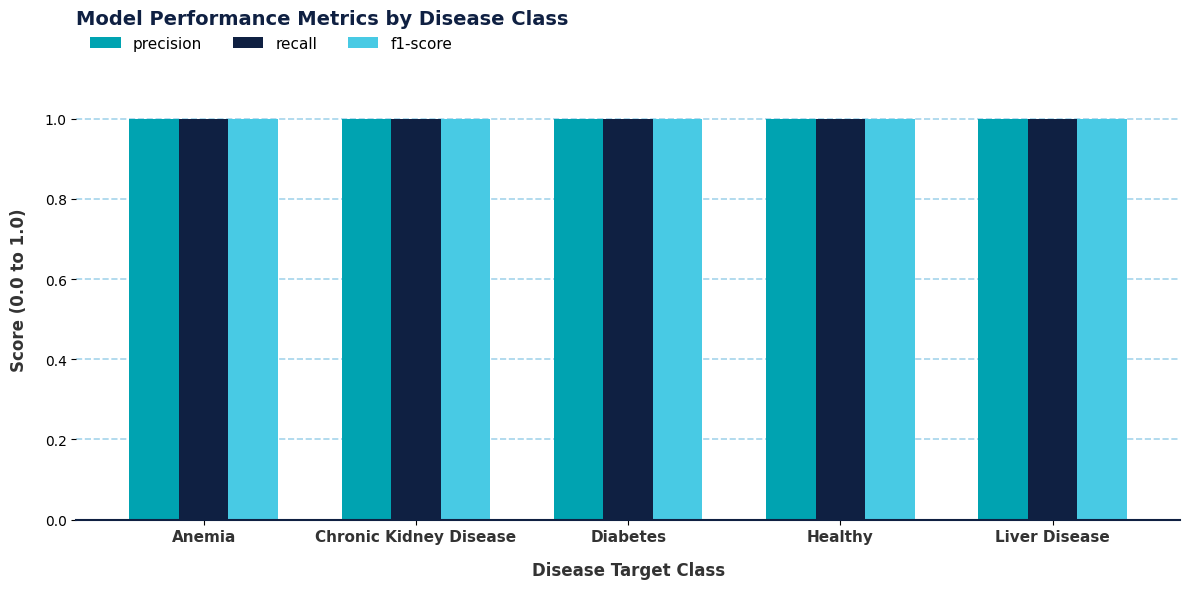

In [40]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, target_names=model.classes_, output_dict=True)
report_df = pd.DataFrame(report).transpose().iloc[:-3, :3]
colors = ['#00A3B1', '#0F2042', '#48CAE4']
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
report_df.plot(
    kind='bar',
    ax=ax,
    color=colors,
    width=0.7,
    edgecolor='none'
)
plt.title('Model Performance Metrics by Disease Class', fontsize=14, fontweight='bold', pad=25, loc='left', color='#0F2042')
plt.xlabel('Disease Target Class', fontsize=12, fontweight='bold', labelpad=12, color='#333333')
plt.ylabel('Score (0.0 to 1.0)', fontsize=12, fontweight='bold', labelpad=12, color='#333333')
plt.ylim(0, 1.15)
plt.legend(title='', frameon=False, loc='upper left', bbox_to_anchor=(0, 1.08), ncol=3, fontsize=11)
plt.xticks(rotation=0, ha='center', fontsize=11, fontweight='bold', color='#333333')
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', color='#8ECAE6', alpha=0.8, linewidth=1.2)
ax.xaxis.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#0F2042')
ax.spines['bottom'].set_linewidth(1.5)
plt.tight_layout()
plt.show()

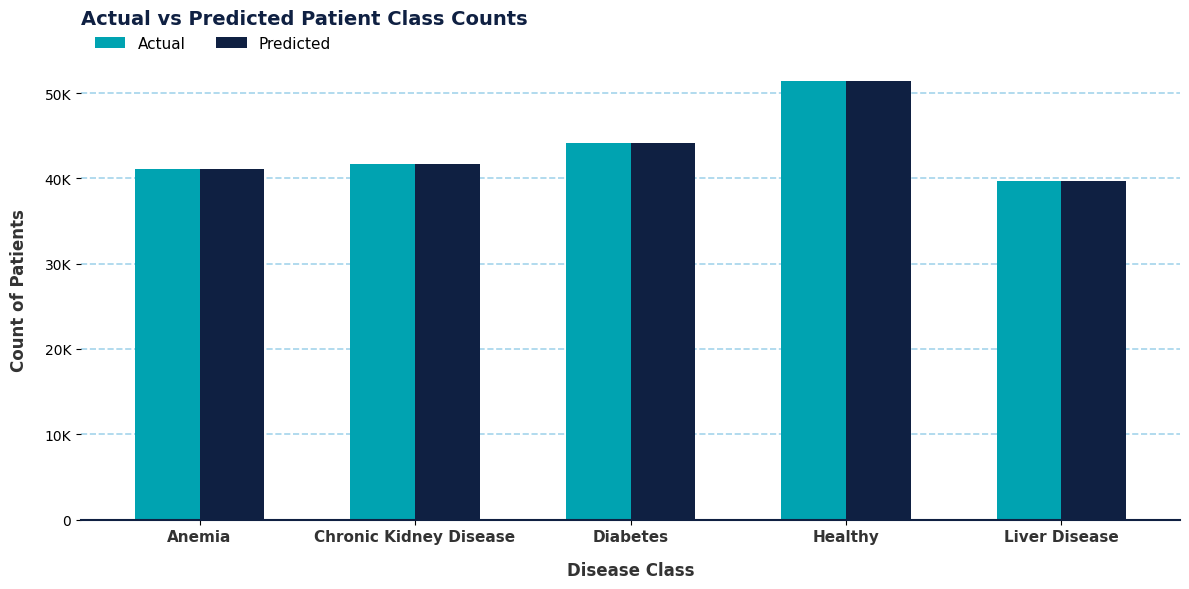

In [41]:
import matplotlib.ticker as ticker


actual_counts = pd.Series(y_test).value_counts().reindex(model.classes_)
pred_counts = pd.Series(y_pred).value_counts().reindex(model.classes_)

comparison_df = pd.DataFrame({
    'Actual': actual_counts,
    'Predicted': pred_counts
})


colors = ['#00A3B1', '#0F2042']

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')


comparison_df.plot(
    kind='bar',
    ax=ax,
    color=colors,
    width=0.6,
    edgecolor='none'
)


plt.title('Actual vs Predicted Patient Class Counts', fontsize=14, fontweight='bold', pad=25, loc='left', color='#0F2042')
plt.xlabel('Disease Class', fontsize=12, fontweight='bold', labelpad=12, color='#333333')
plt.ylabel('Count of Patients', fontsize=12, fontweight='bold', labelpad=12, color='#333333')


plt.legend(title='', frameon=False, loc='upper left', bbox_to_anchor=(0, 1.08), ncol=2, fontsize=11)


plt.xticks(rotation=0, ha='center', fontsize=11, fontweight='bold', color='#333333')


ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', color='#8ECAE6', alpha=0.8, linewidth=1.2)
ax.xaxis.grid(False)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#0F2042')
ax.spines['bottom'].set_linewidth(1.5)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}K' if x >= 1000 else f'{int(x)}'))

plt.tight_layout()
plt.show()


In [42]:
output_file = "MediPredict_Cleaned_Data.csv"

hospital.to_csv(output_file, index=False)

print("CSV created successfully:", output_file)

CSV created successfully: MediPredict_Cleaned_Data.csv
